# 17. Capstone: Anomaly Detection Decision Pipeline

This capstone builds an end-to-end anomaly detection decision system. The emphasis is on turning a detector into a launch-ready workflow: reference data, feature engineering, detector comparison, threshold selection, review capacity, explanation packets, segment diagnostics, privacy-aware audit records, monitoring, and a final decision memo.

The central lesson of the course is the capstone premise:

> An anomaly score is not a decision. A decision requires evidence, thresholds, costs, review capacity, monitoring, governance, and a way to learn from errors.

## Learning Objectives

By the end of this notebook, you should be able to:

- Build a complete anomaly detection workflow from reference data to an alert queue.
- Combine statistical, reconstruction, and isolation-based scores into an auditable ensemble.
- Evaluate detectors with delayed labels, precision-at-capacity, recall, and expected utility.
- Select thresholds under review-capacity and harm constraints.
- Create explanation packets for high-priority alerts.
- Diagnose segment burden and false positive risk before launch.
- Produce a monitoring dashboard, audit log, and launch memo.

## 1. Capstone Scenario

A marketplace platform monitors seller-day activity. Each row summarizes one seller on one day. The platform wants to detect unusual seller behavior that may indicate account takeover, payout abuse, platform instability, or other operational risk.

The system can take four actions:

| Action | Meaning | Operational consequence |
|---|---|---|
| `no_action` | Do not send to queue | No immediate human cost |
| `monitor_known_event` | Suppress to monitoring because a known campaign explains the spike | Avoids burden from benign business events |
| `human_review` | Send to risk or operations analyst | Consumes review capacity |
| `escalate` | Immediate escalation for severe evidence | Higher intervention cost and stronger audit requirement |

This capstone uses simulated data with ground truth labels so we can evaluate the system. In production, labels are delayed and biased toward cases that were reviewed, so these estimates would need correction and monitoring.

## 2. Mathematical Setup

Let $x_i \in \mathbb{R}^p$ be the feature vector for seller-day $i$, and let $y_i \in \{0,1\}$ denote whether the case is eventually confirmed as an incident. A detector produces one or more scores

$$
s_{ij} = f_j(x_i), \qquad j = 1, \ldots, J,
$$

where larger values mean more anomalous.

In this capstone we use three detector families:

1. A transparent robust statistical score.
2. An isolation-based score.
3. A reconstruction score from a low-dimensional normal-operation model.

The ensemble score is a weighted average of calibrated percentile scores:

$$
S_i = \sum_{j=1}^J \alpha_j \widehat{F}_{j,\mathrm{ref}}(s_{ij}),
\qquad \sum_j \alpha_j = 1,
$$

where $\widehat{F}_{j,\mathrm{ref}}$ is the empirical reference cumulative distribution for detector $j$.

A threshold policy maps scores to actions:

$$
a_i = \pi(S_i, e_i, c_i),
$$

where $e_i$ is evidence count and $c_i$ is context such as known campaigns or operational annotations.

For threshold $\tau$, a simple review policy is

$$
R_i(\tau) = \mathbb{1}\{S_i \geq \tau\}.
$$

Given review capacity $B$, a feasible threshold should satisfy

$$
\sum_i R_i(\tau) \leq B.
$$

A launch decision should compare thresholds using utility alongside precision:

$$
U(\tau) = b_{TP} TP(\tau) - c_{FP} FP(\tau) - c_{FN} FN(\tau) - c_R \sum_i R_i(\tau) - c_B \max\{0, \sum_i R_i(\tau) - B\}.
$$

The threshold with the highest utility still needs launch-readiness checks. It must also pass segment, explanation, privacy, and monitoring checks.

## 3. Imports and Display Settings

In [1]:
# Section focus: 3. Imports and Display Settings.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_colwidth', 160)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

print(f'Python: {sys.version.split()[0]}')
print(f'pandas: {pd.__version__}')

Python: 3.12.3
pandas: 3.0.3


## 4. Data-Generating Process

We simulate a reference period and a current monitoring period.

The reference period is mostly normal seller-day behavior. The current period contains four kinds of cases:

| Case type | Label | Operational meaning |
|---|---:|---|
| `normal` | 0 | Typical seller-day behavior |
| `benign_campaign` | 0 | A known promotion creates high volume but is not a risk incident |
| `account_takeover` | 1 | Security-like signals increase sharply |
| `payout_abuse` | 1 | Payout, refund, chargeback, and inventory mismatch signals rise |
| `platform_incident` | 1 | API error, latency, queue, and support signals rise |

The capstone intentionally includes benign campaigns. A detector that cannot distinguish a known business event from a risk incident will waste review capacity.

In [2]:
# Section focus: 4. Data-Generating Process.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

regions = np.array(['North America', 'Europe', 'LATAM', 'APAC'])
seller_tiers = np.array(['enterprise', 'growth', 'long_tail'])
channels = np.array(['web', 'mobile', 'api'])

feature_columns = [
    'log_orders',
    'log_payout_amount',
    'refund_rate',
    'chargeback_rate',
    'failed_login_rate',
    'device_churn',
    'log_geo_jump_km',
    'api_error_rate',
    'log_latency_p95_ms',
    'queue_minutes',
    'support_ticket_rate',
    'inventory_mismatch_rate',
]

feature_labels = {
    'log_orders': 'Order volume',
    'log_payout_amount': 'Payout amount',
    'refund_rate': 'Refund rate',
    'chargeback_rate': 'Chargeback rate',
    'failed_login_rate': 'Failed-login rate',
    'device_churn': 'Device churn',
    'log_geo_jump_km': 'Geo jump distance',
    'api_error_rate': 'API error rate',
    'log_latency_p95_ms': 'Latency p95',
    'queue_minutes': 'Queue delay',
    'support_ticket_rate': 'Support-ticket rate',
    'inventory_mismatch_rate': 'Inventory mismatch rate',
}

feature_weights = pd.Series({
    'log_orders': 0.35,
    'log_payout_amount': 0.70,
    'refund_rate': 0.85,
    'chargeback_rate': 1.10,
    'failed_login_rate': 1.00,
    'device_churn': 0.85,
    'log_geo_jump_km': 0.75,
    'api_error_rate': 0.95,
    'log_latency_p95_ms': 0.75,
    'queue_minutes': 0.75,
    'support_ticket_rate': 0.80,
    'inventory_mismatch_rate': 0.90,
})


def generate_marketplace_period(n, start_date, days, period, seed):
    """Generate marketplace period for the 17. Capstone: Anomaly Detection Decision Pipeline workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    start_date : object
        Time index or time-span setting used by the simulated panel or monitoring window.
    days : object
        Number of days represented in the simulated monitoring window.
    period : object
        Time index or time-span setting used by the simulated panel or monitoring window.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    event_dates = pd.to_datetime(start_date) + pd.to_timedelta(rng.integers(0, days, size=n), unit='D')
    region = rng.choice(regions, size=n, p=[0.46, 0.25, 0.14, 0.15])
    tier = rng.choice(seller_tiers, size=n, p=[0.16, 0.36, 0.48])
    channel = rng.choice(channels, size=n, p=[0.47, 0.35, 0.18])

    tier_order_mu = {'enterprise': 6.2, 'growth': 4.8, 'long_tail': 3.5}
    tier_payout_mu = {'enterprise': 9.8, 'growth': 8.1, 'long_tail': 6.6}
    region_error_bump = {'North America': 0.00, 'Europe': 0.05, 'LATAM': 0.10, 'APAC': 0.08}
    channel_latency_bump = {'web': 0.0, 'mobile': 0.08, 'api': 0.20}

    orders = np.array([rng.lognormal(tier_order_mu[t], 0.38) for t in tier])
    payout_amount = np.array([rng.lognormal(tier_payout_mu[t], 0.52) for t in tier])
    refund_rate = rng.beta(1.4, 48, size=n) + 0.003 * (tier == 'enterprise')
    chargeback_rate = rng.beta(0.7, 95, size=n) + 0.002 * (channel == 'mobile')
    failed_login_rate = rng.beta(1.1, 90, size=n) + 0.006 * (channel == 'mobile')
    device_churn = rng.gamma(1.3 + 0.35 * (channel == 'mobile'), 0.75, size=n)
    geo_jump_km = rng.gamma(1.4 + 0.25 * (region == 'APAC'), 145, size=n)
    api_error_rate = rng.beta(0.9, 140, size=n) + np.array([region_error_bump[r] for r in region]) / 100
    latency_p95_ms = rng.lognormal(5.0 + np.array([channel_latency_bump[c] for c in channel]), 0.22, size=n)
    queue_minutes = rng.gamma(1.1, 1.4, size=n) + 0.5 * (tier == 'enterprise')
    support_ticket_rate = rng.beta(1.2, 75, size=n)
    inventory_mismatch_rate = rng.beta(1.0, 85, size=n) + 0.003 * (tier == 'long_tail')

    anomaly_type = np.array(['normal'] * n, dtype=object)
    confirmed_incident = np.zeros(n, dtype=int)
    known_event = np.zeros(n, dtype=int)

    if period == 'current':
        benign_idx = rng.choice(n, size=int(0.055 * n), replace=False)
        remaining = np.setdiff1d(np.arange(n), benign_idx)
        takeover_idx = rng.choice(remaining, size=int(0.030 * n), replace=False)
        remaining = np.setdiff1d(remaining, takeover_idx)
        payout_idx = rng.choice(remaining, size=int(0.025 * n), replace=False)
        remaining = np.setdiff1d(remaining, payout_idx)
        platform_idx = rng.choice(remaining, size=int(0.020 * n), replace=False)

        anomaly_type[benign_idx] = 'benign_campaign'
        known_event[benign_idx] = 1
        orders[benign_idx] *= rng.uniform(2.0, 4.0, size=len(benign_idx))
        payout_amount[benign_idx] *= rng.uniform(1.5, 2.7, size=len(benign_idx))
        support_ticket_rate[benign_idx] += rng.beta(1.2, 70, size=len(benign_idx))

        anomaly_type[takeover_idx] = 'account_takeover'
        confirmed_incident[takeover_idx] = 1
        failed_login_rate[takeover_idx] += rng.uniform(0.08, 0.28, size=len(takeover_idx))
        device_churn[takeover_idx] += rng.gamma(3.0, 1.2, size=len(takeover_idx))
        geo_jump_km[takeover_idx] += rng.gamma(2.8, 420, size=len(takeover_idx))
        chargeback_rate[takeover_idx] += rng.uniform(0.015, 0.06, size=len(takeover_idx))

        anomaly_type[payout_idx] = 'payout_abuse'
        confirmed_incident[payout_idx] = 1
        payout_amount[payout_idx] *= rng.uniform(3.0, 7.0, size=len(payout_idx))
        refund_rate[payout_idx] += rng.uniform(0.04, 0.18, size=len(payout_idx))
        chargeback_rate[payout_idx] += rng.uniform(0.02, 0.12, size=len(payout_idx))
        inventory_mismatch_rate[payout_idx] += rng.uniform(0.03, 0.16, size=len(payout_idx))

        anomaly_type[platform_idx] = 'platform_incident'
        confirmed_incident[platform_idx] = 1
        api_error_rate[platform_idx] += rng.uniform(0.05, 0.22, size=len(platform_idx))
        latency_p95_ms[platform_idx] *= rng.uniform(2.1, 4.0, size=len(platform_idx))
        queue_minutes[platform_idx] += rng.gamma(5.0, 3.0, size=len(platform_idx))
        support_ticket_rate[platform_idx] += rng.uniform(0.05, 0.20, size=len(platform_idx))

    df = pd.DataFrame({
        'case_id': [f'{period}_{i:05d}' for i in range(n)],
        'event_date': event_dates,
        'region': region,
        'seller_tier': tier,
        'channel': channel,
        'orders': orders,
        'payout_amount': payout_amount,
        'refund_rate': np.clip(refund_rate, 0, 1),
        'chargeback_rate': np.clip(chargeback_rate, 0, 1),
        'failed_login_rate': np.clip(failed_login_rate, 0, 1),
        'device_churn': device_churn,
        'geo_jump_km': geo_jump_km,
        'api_error_rate': np.clip(api_error_rate, 0, 1),
        'latency_p95_ms': latency_p95_ms,
        'queue_minutes': queue_minutes,
        'support_ticket_rate': np.clip(support_ticket_rate, 0, 1),
        'inventory_mismatch_rate': np.clip(inventory_mismatch_rate, 0, 1),
        'anomaly_type': anomaly_type,
        'confirmed_incident': confirmed_incident,
        'known_event': known_event,
        'period': period,
    })
    return df

reference = generate_marketplace_period(9000, '2026-01-01', 60, 'reference', RANDOM_SEED)
current = generate_marketplace_period(6500, '2026-03-02', 21, 'current', RANDOM_SEED + 1)

summary = pd.DataFrame([
    {'period': 'reference', 'rows': len(reference), 'confirmed_incident_rate': reference['confirmed_incident'].mean(), 'known_event_rate': reference['known_event'].mean()},
    {'period': 'current', 'rows': len(current), 'confirmed_incident_rate': current['confirmed_incident'].mean(), 'known_event_rate': current['known_event'].mean()},
])
summary

,period,rows,confirmed_incident_rate,known_event_rate
0,reference,9000,0.000000,0.000000
1,current,6500,0.074923,0.054923


The reference period is used to learn normal behavior. The current period is used to score and evaluate the launch policy. In a real deployment, the current labels would arrive slowly through human review, customer reports, chargebacks, system tickets, and post-incident analysis.

For Data-Generating Process, focus on what the alert would make an analyst do next: investigate, suppress, monitor, or revise the rule.


## 5. Feature Engineering and Detector Training

The pipeline uses numeric engineered features. Skewed monetary, count, distance, and latency variables are log-transformed before scaling.

In [3]:
# Section focus: 5. Feature Engineering and Detector Training.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_features(df):
    """Construct the features helper used in the 17. Capstone: Anomaly Detection Decision Pipeline workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the features workflow for later analysis.
    """
    X = pd.DataFrame(index=df.index)
    X['log_orders'] = np.log1p(df['orders'])
    X['log_payout_amount'] = np.log1p(df['payout_amount'])
    X['refund_rate'] = df['refund_rate']
    X['chargeback_rate'] = df['chargeback_rate']
    X['failed_login_rate'] = df['failed_login_rate']
    X['device_churn'] = df['device_churn']
    X['log_geo_jump_km'] = np.log1p(df['geo_jump_km'])
    X['api_error_rate'] = df['api_error_rate']
    X['log_latency_p95_ms'] = np.log1p(df['latency_p95_ms'])
    X['queue_minutes'] = df['queue_minutes']
    X['support_ticket_rate'] = df['support_ticket_rate']
    X['inventory_mismatch_rate'] = df['inventory_mismatch_rate']
    return X[feature_columns]

X_ref_raw = make_features(reference)
X_cur_raw = make_features(current)

scaler = StandardScaler()
X_ref = scaler.fit_transform(X_ref_raw)
X_cur = scaler.transform(X_cur_raw)

iso = IsolationForest(
    n_estimators=350,
    max_samples=512,
    contamination='auto',
    random_state=RANDOM_SEED,
)
iso.fit(X_ref)

pca = PCA(n_components=5, random_state=RANDOM_SEED)
pca.fit(X_ref)

print(f'Reference matrix: {X_ref.shape}')
print(f'Current matrix: {X_cur.shape}')
print(f'PCA explained variance with 5 components: {pca.explained_variance_ratio_.sum():.3f}')

Reference matrix: (9000, 12)
Current matrix: (6500, 12)
PCA explained variance with 5 components: 0.503


We train only on reference behavior. This is not because the reference period is perfectly normal. It is because production anomaly detection often starts from a pragmatic baseline: learn from a reasonably stable period, then challenge the detector with review feedback and drift monitoring.

Feature Engineering and Detector Training should be read as an operations question. Ask whether the score isolates a real review priority or mostly reflects routine variation and noise.


## 6. Detector Scores and Ensemble Calibration

The capstone uses three score families.

### Robust Statistical Score

For feature $k$, define a robust z-score from the reference period:

$$
z_{ik} = \frac{x_{ik} - \mathrm{median}(x_{\mathrm{ref},k})}{1.4826 \cdot \mathrm{MAD}(x_{\mathrm{ref},k}) + \epsilon}.
$$

The robust score keeps the positive side for high-risk features and aggregates weighted squared deviations:

$$
r_i = \sqrt{\frac{\sum_k w_k \max(z_{ik},0)^2}{\sum_k w_k}}.
$$

### Isolation Score

Isolation Forest is used as an isolation-based detector; it is designed around the idea that anomalous points can be isolated with fewer random splits than typical points (Liu et al., 2008, 2012).

### Reconstruction Score

The PCA reconstruction score measures how poorly a case is reconstructed by a low-dimensional normal-operation model:

$$
e_i = \lVert x_i - \widehat{x}_i \rVert_2^2.
$$

In [4]:
# Section focus: Reconstruction Score.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def empirical_percentile(reference_scores, scores):
    """Carry out the empirical percentile step used in the 17. Capstone: Anomaly Detection Decision Pipeline workflow.
    
    Parameters
    ----------
    reference_scores : object
        Score or risk value used for ranking, thresholding, or diagnostics.
    scores : object
        Model scores, risks, or anomaly scores used by the decision rule.
    
    Returns
    -------
    object
        Intermediate result produced by the empirical percentile calculation and reused by later cells.
    """
    ref_sorted = np.sort(np.asarray(reference_scores))
    return np.searchsorted(ref_sorted, scores, side='right') / len(ref_sorted)

ref_median = X_ref_raw.median()
ref_mad = (X_ref_raw - ref_median).abs().median().replace(0, 1e-6)

def robust_score(X_raw):
    """Carry out the robust score step used in the 17. Capstone: Anomaly Detection Decision Pipeline workflow.
    
    Parameters
    ----------
    X_raw : object
        Feature row, feature matrix, or covariate value passed into the model workflow.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the robust score calculation.
    """
    z = (X_raw - ref_median) / (1.4826 * ref_mad + 1e-6)
    z_pos = z.clip(lower=0)
    weighted = z_pos.pow(2).multiply(feature_weights, axis=1)
    return np.sqrt(weighted.sum(axis=1) / feature_weights.sum())

ref_robust = robust_score(X_ref_raw)
cur_robust = robust_score(X_cur_raw)

ref_iforest_raw = -iso.decision_function(X_ref)
cur_iforest_raw = -iso.decision_function(X_cur)

ref_pca_recon = pca.inverse_transform(pca.transform(X_ref))
cur_pca_recon = pca.inverse_transform(pca.transform(X_cur))
ref_pca_error = np.mean((X_ref - ref_pca_recon) ** 2, axis=1)
cur_pca_error = np.mean((X_cur - cur_pca_recon) ** 2, axis=1)

scores = current.copy()
scores['robust_score_raw'] = cur_robust
scores['iforest_score_raw'] = cur_iforest_raw
scores['pca_error_raw'] = cur_pca_error
scores['robust_pct'] = empirical_percentile(ref_robust, cur_robust)
scores['iforest_pct'] = empirical_percentile(ref_iforest_raw, cur_iforest_raw)
scores['pca_pct'] = empirical_percentile(ref_pca_error, cur_pca_error)
scores['ensemble_score'] = 0.38 * scores['robust_pct'] + 0.34 * scores['iforest_pct'] + 0.28 * scores['pca_pct']

# Evidence families used for action rules and explanations.
robust_z_current = (X_cur_raw - ref_median) / (1.4826 * ref_mad + 1e-6)
scores['security_evidence_count'] = (
    (robust_z_current['failed_login_rate'] > 2.0).astype(int)
    + (robust_z_current['device_churn'] > 2.0).astype(int)
    + (robust_z_current['log_geo_jump_km'] > 2.2).astype(int)
    + (robust_z_current['chargeback_rate'] > 2.0).astype(int)
)
scores['financial_evidence_count'] = (
    (robust_z_current['log_payout_amount'] > 2.2).astype(int)
    + (robust_z_current['refund_rate'] > 2.0).astype(int)
    + (robust_z_current['chargeback_rate'] > 2.0).astype(int)
    + (robust_z_current['inventory_mismatch_rate'] > 2.0).astype(int)
)
scores['operations_evidence_count'] = (
    (robust_z_current['api_error_rate'] > 2.0).astype(int)
    + (robust_z_current['log_latency_p95_ms'] > 2.0).astype(int)
    + (robust_z_current['queue_minutes'] > 2.0).astype(int)
    + (robust_z_current['support_ticket_rate'] > 2.0).astype(int)
)
scores['evidence_count'] = (
    scores['security_evidence_count']
    + scores['financial_evidence_count']
    + scores['operations_evidence_count']
)

score_summary = scores[['robust_pct', 'iforest_pct', 'pca_pct', 'ensemble_score', 'evidence_count']].describe().round(3)
score_summary

,robust_pct,iforest_pct,pca_pct,ensemble_score,evidence_count
count,6500.000,6500.000,6500.000,6500.000,6500.000
mean,0.541,0.544,0.546,0.543,1.384
std,0.306,0.307,0.308,0.288,1.471
min,0.000,0.000,0.000,0.006,0.000
25%,0.276,0.274,0.281,0.299,0.000
50%,0.548,0.546,0.555,0.532,1.000
75%,0.810,0.820,0.821,0.790,2.000
max,1.000,1.000,1.000,1.000,8.000


Percentile calibration makes heterogeneous scores easier to combine and explain. A score of 0.99 means the case is more extreme than roughly 99 percent of the reference period under that detector.

In Reconstruction Score, the detector earns its keep only if the output sharpens the review queue.


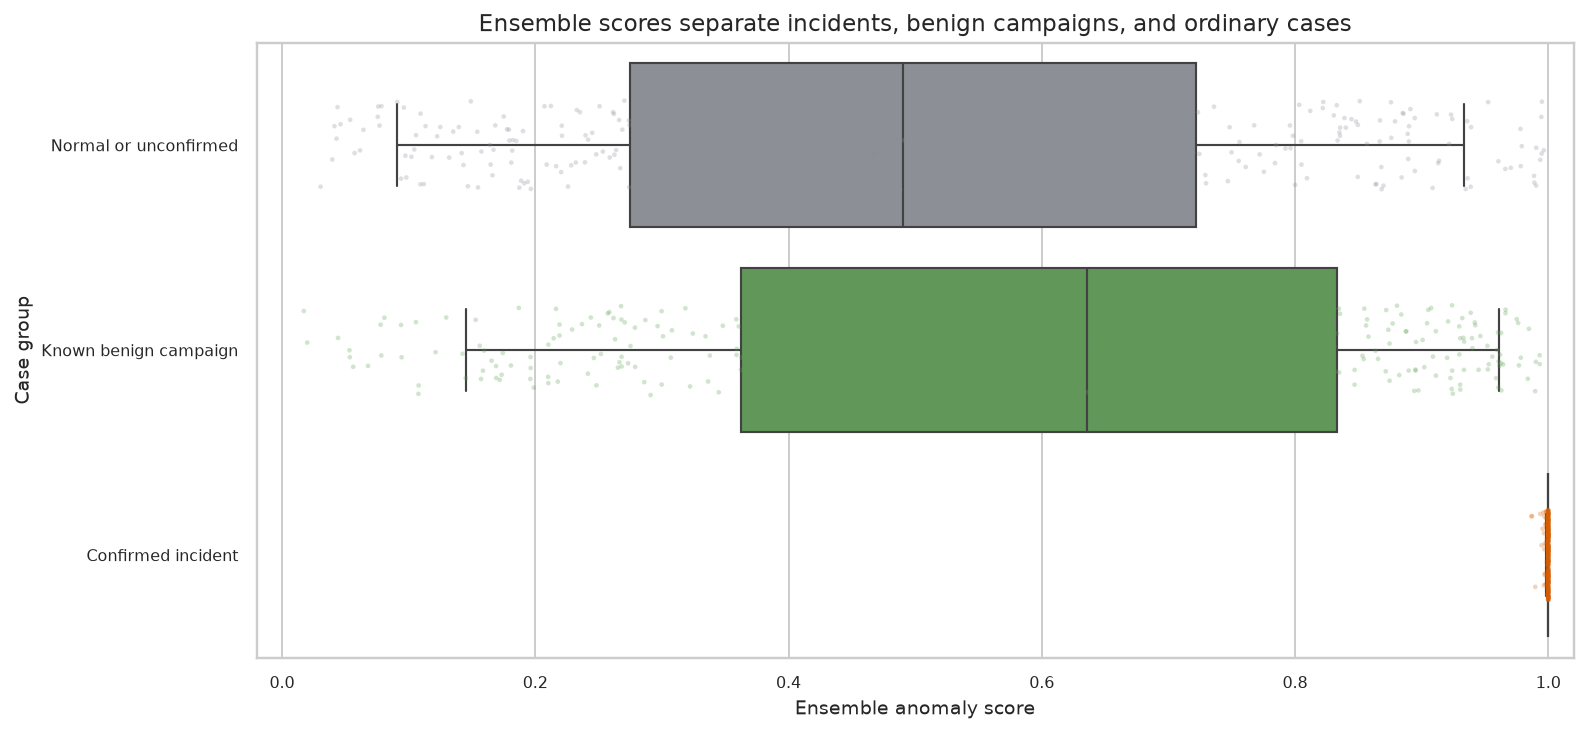

In [5]:
# Section focus: Reconstruction Score.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, ax = plt.subplots(figsize=(11.5, 5.4))
plot_df = scores.copy()
plot_df['case_group'] = np.where(
    plot_df['confirmed_incident'].eq(1),
    'Confirmed incident',
    np.where(plot_df['known_event'].eq(1), 'Known benign campaign', 'Normal or unconfirmed'),
)
case_order = ['Normal or unconfirmed', 'Known benign campaign', 'Confirmed incident']
case_palette = {
    'Normal or unconfirmed': '#8a8f98',
    'Known benign campaign': '#59a14f',
    'Confirmed incident': '#d95f02',
}
strip_sample = pd.concat(
    [g.sample(min(len(g), 350), random_state=7) for _, g in plot_df.groupby('case_group')],
    ignore_index=True,
)
sns.boxplot(
    data=plot_df,
    x='ensemble_score',
    y='case_group',
    hue='case_group',
    order=case_order,
    hue_order=case_order,
    palette=case_palette,
    whis=(5, 95),
    showfliers=False,
    linewidth=1.1,
    legend=False,
    ax=ax,
)
sns.stripplot(
    data=strip_sample,
    x='ensemble_score',
    y='case_group',
    hue='case_group',
    order=case_order,
    hue_order=case_order,
    palette=case_palette,
    jitter=0.22,
    alpha=0.28,
    size=2.4,
    legend=False,
    ax=ax,
)
ax.set_title('Ensemble scores separate incidents, benign campaigns, and ordinary cases')
ax.set_xlabel('Ensemble anomaly score')
ax.set_ylabel('Case group')
ax.set_xlim(-0.02, 1.02)
plt.tight_layout()
plt.show()

The score distribution already tells a launch story: confirmed incidents are shifted toward high scores, but known benign campaigns can also enter the high-score tail. The policy therefore needs business annotations and evidence rules alongside a threshold.

The practical reading of Reconstruction Score is whether the flagged cases point to an action a team can defend.


## 7. Detector Comparison

Because simulated current labels are available, we can compare detectors using standard ranking metrics. In production, these labels would be delayed and biased, so this would be supplemented by review sampling and synthetic injection tests.

In [6]:
# Section focus: 7. Detector Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def precision_at_k(y_true, score, k):
    """Carry out the precision at k step used in the 17. Capstone: Anomaly Detection Decision Pipeline workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    k : object
        Count or size setting for the precision at k calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the precision at k calculation and reused by later cells.
    """
    k = min(k, len(y_true))
    top_idx = np.argsort(score)[::-1][:k]
    return np.mean(np.asarray(y_true)[top_idx])


def recall_at_k(y_true, score, k):
    """Carry out the recall at k step used in the 17. Capstone: Anomaly Detection Decision Pipeline workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    k : object
        Count or size setting for the recall at k calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the recall at k calculation and reused by later cells.
    """
    k = min(k, len(y_true))
    y = np.asarray(y_true)
    top_idx = np.argsort(score)[::-1][:k]
    return y[top_idx].sum() / max(y.sum(), 1)

label = scores['confirmed_incident'].to_numpy()
detectors = {
    'Robust statistical': scores['robust_pct'].to_numpy(),
    'Isolation Forest': scores['iforest_pct'].to_numpy(),
    'PCA reconstruction': scores['pca_pct'].to_numpy(),
    'Weighted ensemble': scores['ensemble_score'].to_numpy(),
}

rows = []
for name, score in detectors.items():
    rows.append({
        'detector': name,
        'average_precision': average_precision_score(label, score),
        'roc_auc': roc_auc_score(label, score),
        'precision_at_300': precision_at_k(label, score, 300),
        'precision_at_600': precision_at_k(label, score, 600),
        'recall_at_600': recall_at_k(label, score, 600),
    })
comparison_table = pd.DataFrame(rows).sort_values('average_precision', ascending=False)
comparison_table.round(3)

,detector,average_precision,roc_auc,precision_at_300,precision_at_600,recall_at_600
3,Weighted ensemble,0.998,1.000,1.000,0.812,1.000
0,Robust statistical,0.993,1.000,1.000,0.812,1.000
2,PCA reconstruction,0.989,0.999,0.997,0.803,0.990
1,Isolation Forest,0.985,0.999,0.990,0.810,0.998


For Detector Comparison, separate unusual behavior from useful triage. The alert is valuable only when it changes the next review step.


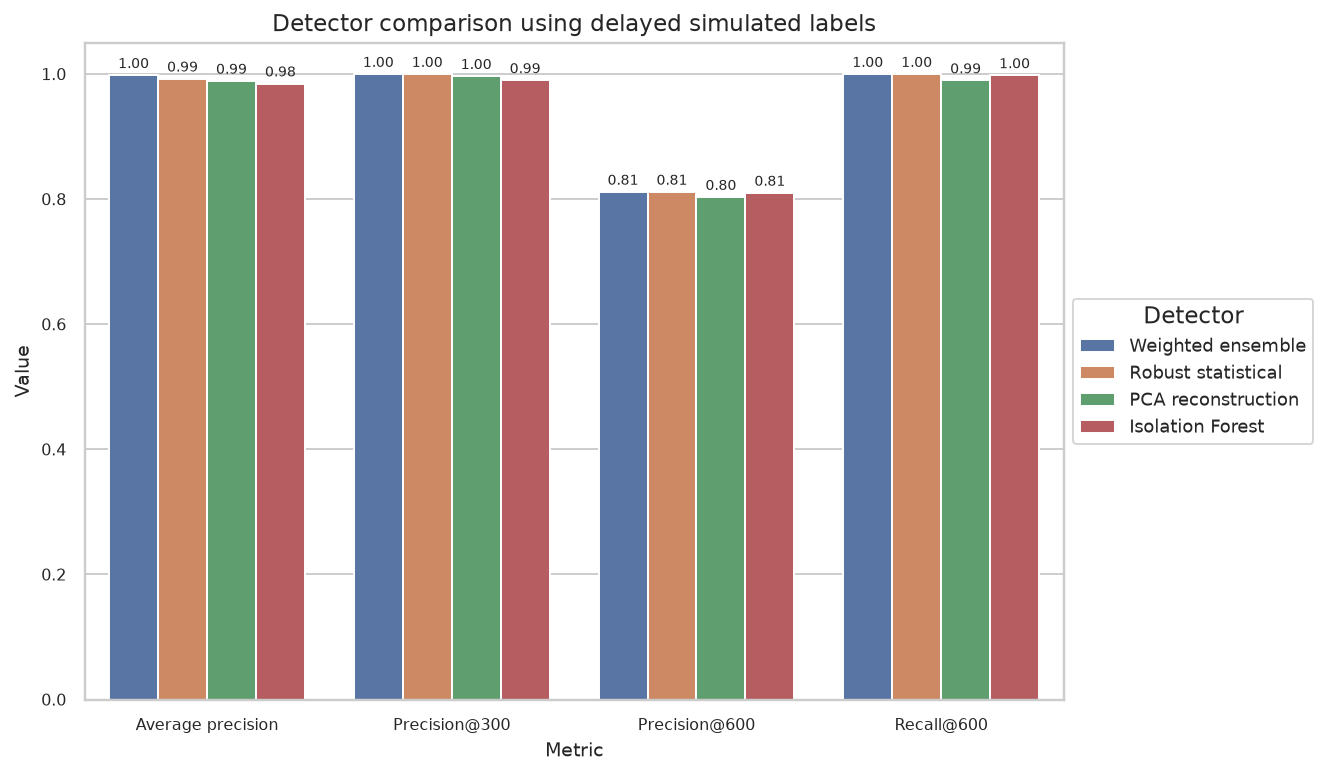

In [7]:
# Section focus: 7. Detector Comparison.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

comparison_long = comparison_table.melt(
    id_vars='detector',
    value_vars=['average_precision', 'precision_at_300', 'precision_at_600', 'recall_at_600'],
    var_name='metric',
    value_name='value',
)
metric_names = {
    'average_precision': 'Average precision',
    'precision_at_300': 'Precision@300',
    'precision_at_600': 'Precision@600',
    'recall_at_600': 'Recall@600',
}
comparison_long['metric'] = comparison_long['metric'].map(metric_names)

fig, ax = plt.subplots(figsize=(11.5, 5.7))
sns.barplot(data=comparison_long, x='metric', y='value', hue='detector', ax=ax)
ax.set_title('Detector comparison using delayed simulated labels')
ax.set_xlabel('Metric')
ax.set_ylabel('Value')
ax.set_ylim(0, 1.05)
ax.legend(title='Detector', frameon=True, loc='center left', bbox_to_anchor=(1.01, 0.5), borderaxespad=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

The ensemble is not guaranteed to dominate every metric. Its value is operational: it stabilizes a decision pipeline by combining complementary evidence streams. A launch decision should still inspect failures, segment burden, and capacity.

Detector Comparison is less about the score itself and more about whether the score creates an actionable investigation path.


## 8. Threshold Selection Under Capacity and Costs

We choose a review threshold by expected utility, subject to a review-capacity penalty. The utility numbers are illustrative and should be replaced by business estimates in a real deployment.

In [8]:
# Section focus: 8. Threshold Selection Under Capacity and Costs.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

review_capacity = 650
benefit_tp = 1300
cost_fp = 180
cost_fn = 850
review_cost = 55
over_capacity_penalty = 240

thresholds = np.quantile(scores['ensemble_score'], np.linspace(0.72, 0.985, 70))
frontier_rows = []
y = scores['confirmed_incident'].to_numpy()
for tau in thresholds:
    acted = scores['ensemble_score'].ge(tau).to_numpy()
    tp = ((acted) & (y == 1)).sum()
    fp = ((acted) & (y == 0)).sum()
    fn = ((~acted) & (y == 1)).sum()
    volume = acted.sum()
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    utility = (
        benefit_tp * tp
        - cost_fp * fp
        - cost_fn * fn
        - review_cost * volume
        - over_capacity_penalty * max(volume - review_capacity, 0)
    )
    frontier_rows.append({
        'threshold': tau,
        'review_volume': volume,
        'precision': precision,
        'recall': recall,
        'utility': utility,
        'over_capacity': volume > review_capacity,
    })
frontier = pd.DataFrame(frontier_rows)
best_row = frontier.sort_values('utility', ascending=False).iloc[0]
review_threshold = float(best_row['threshold'])
escalation_threshold = float(np.quantile(scores['ensemble_score'], 0.987))

pd.DataFrame([
    {'quantity': 'Selected review threshold', 'value': review_threshold},
    {'quantity': 'Escalation score threshold', 'value': escalation_threshold},
    {'quantity': 'Expected review volume at selected threshold', 'value': int(best_row['review_volume'])},
    {'quantity': 'Precision at selected threshold', 'value': best_row['precision']},
    {'quantity': 'Recall at selected threshold', 'value': best_row['recall']},
    {'quantity': 'Utility at selected threshold', 'value': best_row['utility']},
]).round(3)

,quantity,value
0,Selected review threshold,0.983
1,Escalation score threshold,1.000
2,Expected review volume at selected threshold,547.000
3,Precision at selected threshold,0.890
4,Recall at selected threshold,1.000
5,Utility at selected threshold,592215.000


This output matters because anomaly detection is both a scoring exercise and an operating system. For Threshold Selection Under Capacity and Costs, the result should tell us which alerts are actionable, which are ambiguous, and where human review is needed. The implication is a triage policy with an investigation path.


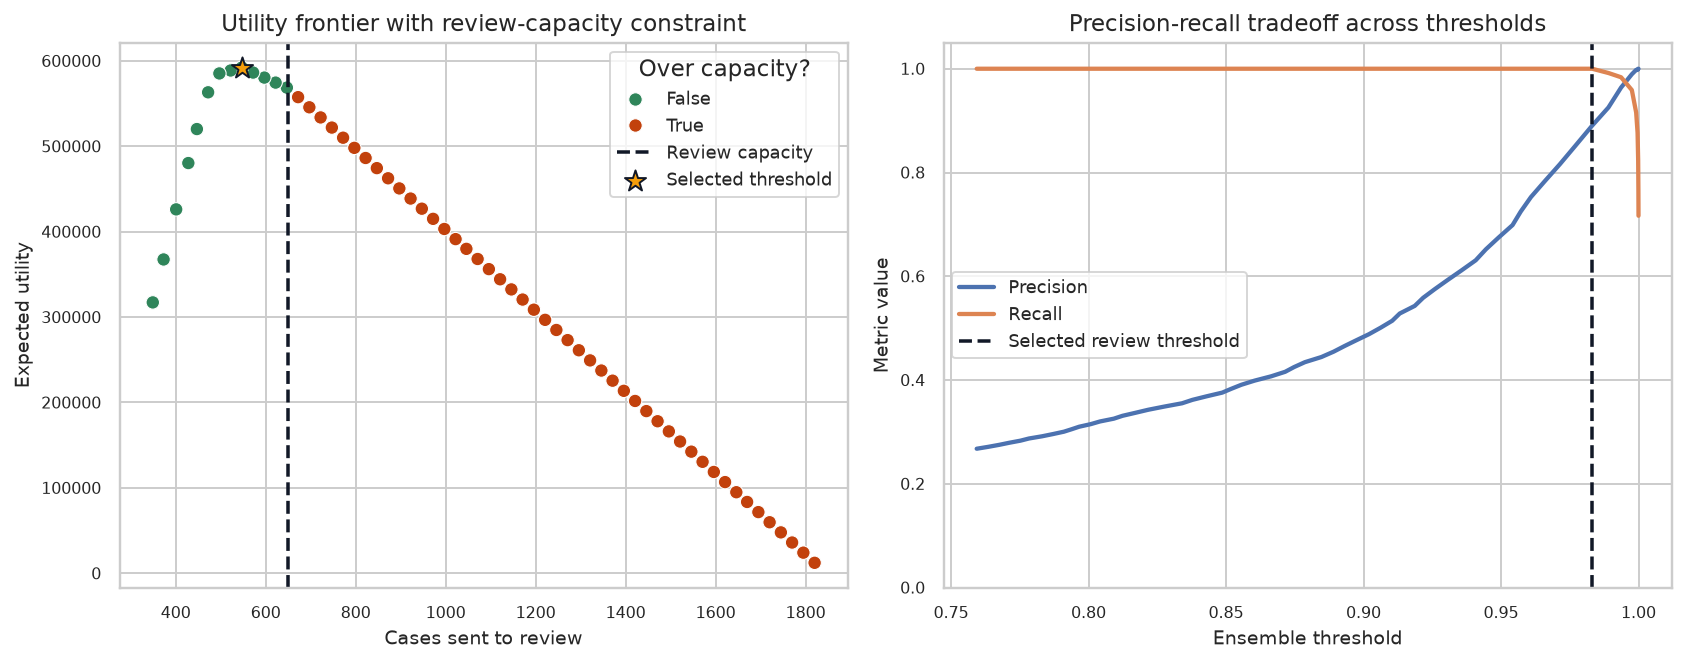

In [9]:
# Section focus: 8. Threshold Selection Under Capacity and Costs.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.9))

sns.scatterplot(
    data=frontier,
    x='review_volume',
    y='utility',
    hue='over_capacity',
    palette={False: '#2f855a', True: '#c2410c'},
    s=48,
    ax=axes[0],
)
axes[0].axvline(review_capacity, color='#111827', linestyle='--', linewidth=1.8, label='Review capacity')
axes[0].scatter(best_row['review_volume'], best_row['utility'], s=130, marker='*', color='#f59e0b', edgecolor='#111827', label='Selected threshold', zorder=5)
axes[0].set_title('Utility frontier with review-capacity constraint')
axes[0].set_xlabel('Cases sent to review')
axes[0].set_ylabel('Expected utility')
axes[0].legend(title='Over capacity?', frameon=True)

sns.lineplot(data=frontier.sort_values('threshold'), x='threshold', y='precision', label='Precision', linewidth=2.2, ax=axes[1])
sns.lineplot(data=frontier.sort_values('threshold'), x='threshold', y='recall', label='Recall', linewidth=2.2, ax=axes[1])
axes[1].axvline(review_threshold, color='#111827', linestyle='--', linewidth=1.8, label='Selected review threshold')
axes[1].set_title('Precision-recall tradeoff across thresholds')
axes[1].set_xlabel('Ensemble threshold')
axes[1].set_ylabel('Metric value')
axes[1].set_ylim(0, 1.05)
axes[1].legend(frameon=True, loc='center left')
plt.tight_layout()
plt.show()

The selected threshold is not chosen only because it has good recall. It is chosen because it balances caught incidents, false positives, missed incidents, review cost, and queue capacity.

Read Threshold Selection Under Capacity and Costs with the reviewer in mind. A useful detector narrows the review queue rather than widening it.


## 9. Decision Policy and Alert Queue

The launch policy uses the selected threshold, evidence counts, and known-event annotations.

Rules:

1. Escalate cases above the escalation threshold when at least four evidence families are active.
2. Suppress high-scoring known campaigns to monitoring if evidence is mostly volume-only.
3. Send remaining high-scoring cases to human review.
4. Do nothing for cases below the review threshold.

In [10]:
scores['action'] = 'no_action'

# Known business events should not automatically consume the human-review queue.
# The monitor threshold is intentionally lower than the review threshold so the
# policy can suppress high-but-explainable campaign spikes before they reach review.
known_event_monitor_threshold = min(review_threshold, 0.90)

risk_evidence_excluding_volume = (
    scores['security_evidence_count']
    + scores['operations_evidence_count']
    + (robust_z_current['refund_rate'] > 2).astype(int).to_numpy()
    + (robust_z_current['chargeback_rate'] > 2).astype(int).to_numpy()
    + (robust_z_current['inventory_mismatch_rate'] > 2).astype(int).to_numpy()
)
scores['risk_evidence_excluding_volume'] = risk_evidence_excluding_volume

volume_only_known_event = (
    scores['known_event'].eq(1)
    & scores['ensemble_score'].ge(known_event_monitor_threshold)
    & scores['risk_evidence_excluding_volume'].le(1)
)
escalate = scores['ensemble_score'].ge(escalation_threshold) & scores['evidence_count'].ge(4)
human_review = scores['ensemble_score'].ge(review_threshold) & ~volume_only_known_event & ~escalate

scores.loc[volume_only_known_event, 'action'] = 'monitor_known_event'
scores.loc[human_review, 'action'] = 'human_review'
scores.loc[escalate, 'action'] = 'escalate'

acted = scores['action'].isin(['human_review', 'escalate'])
policy_summary = pd.DataFrame([
    {'metric': 'Rows in current period', 'value': len(scores)},
    {'metric': 'Human reviews', 'value': int(scores['action'].eq('human_review').sum())},
    {'metric': 'Escalations', 'value': int(scores['action'].eq('escalate').sum())},
    {'metric': 'Known events monitored instead of reviewed', 'value': int(scores['action'].eq('monitor_known_event').sum())},
    {'metric': 'Known-event monitor threshold', 'value': known_event_monitor_threshold},
    {'metric': 'Precision among reviewed or escalated cases', 'value': scores.loc[acted, 'confirmed_incident'].mean()},
    {'metric': 'Recall among confirmed incidents', 'value': scores.loc[acted, 'confirmed_incident'].sum() / max(scores['confirmed_incident'].sum(), 1)},
])
policy_summary

,metric,value
0,Rows in current period,6500.000000
1,Human reviews,202.000000
2,Escalations,345.000000
3,Known events monitored instead of reviewed,12.000000
4,Known-event monitor threshold,0.900000
5,Precision among reviewed or escalated cases,0.890311
6,Recall among confirmed incidents,1.000000


This output matters because anomaly detection is both a scoring exercise and an operating system. For Decision Policy and Alert Queue, the result should tell us which alerts are actionable, which are ambiguous, and where human review is needed. The implication is a triage policy with an investigation path.


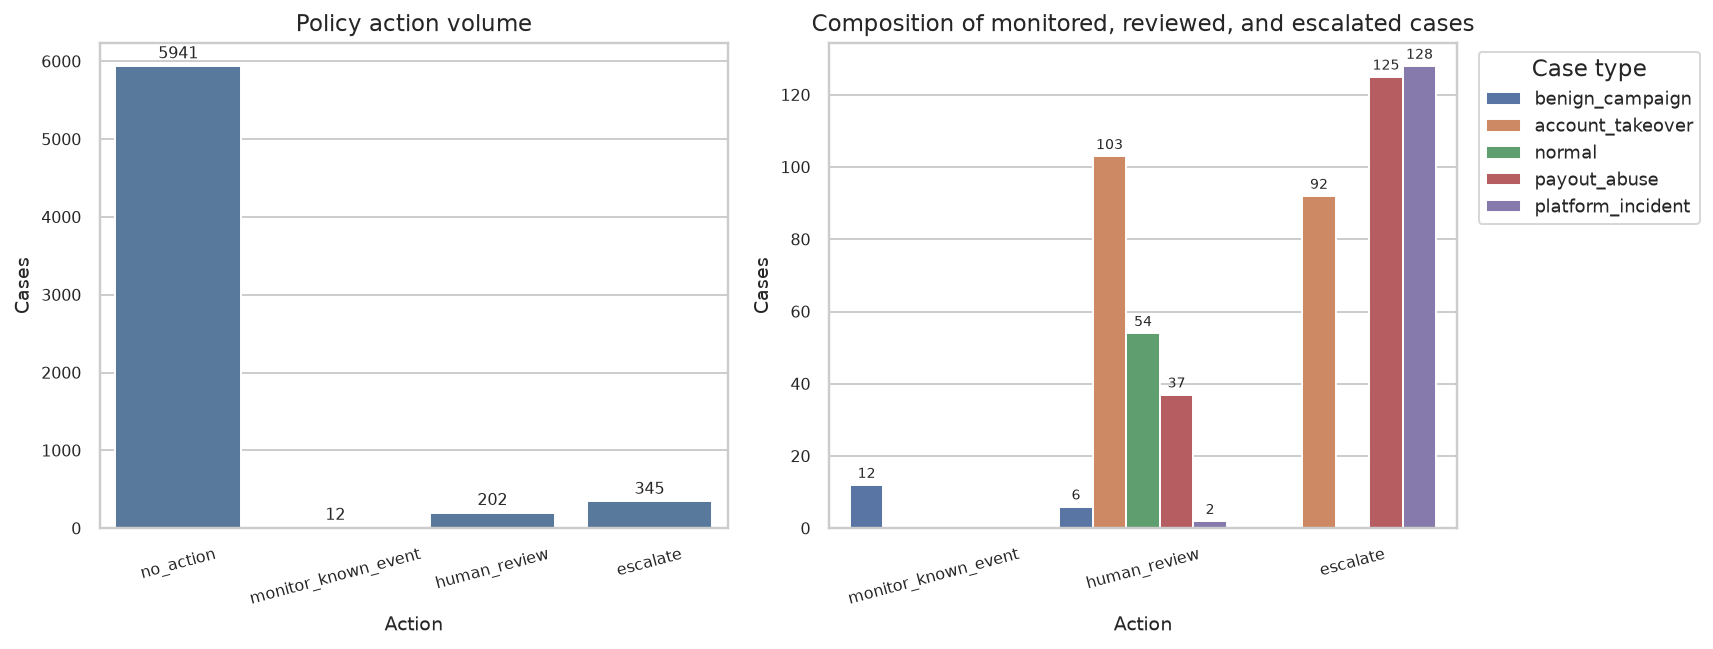

In [11]:
# Section focus: 9. Decision Policy and Alert Queue.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

action_order = ['no_action', 'monitor_known_event', 'human_review', 'escalate']
action_counts = scores['action'].value_counts().reindex(action_order, fill_value=0).reset_index()
action_counts.columns = ['action', 'count']

action_type = (
    scores.groupby(['action', 'anomaly_type'])
    .size()
    .reset_index(name='count')
)

action_type['action'] = pd.Categorical(action_type['action'], categories=action_order, ordered=True)
review_actions = ['monitor_known_event', 'human_review', 'escalate']
action_type_focus = action_type.loc[action_type['action'].isin(review_actions)].copy()

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))
sns.barplot(data=action_counts, x='action', y='count', color='#4c78a8', ax=axes[0])
axes[0].set_title('Policy action volume')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('Cases')
axes[0].tick_params(axis='x', rotation=15)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', fontsize=8, padding=2)

sns.barplot(data=action_type_focus.sort_values('action'), x='action', y='count', hue='anomaly_type', order=review_actions, ax=axes[1])
axes[1].set_title('Composition of monitored, reviewed, and escalated cases')
axes[1].set_xlabel('Action')
axes[1].set_ylabel('Cases')
axes[1].tick_params(axis='x', rotation=15)
for container in axes[1].containers:
    labels = [f'{v.get_height():.0f}' if v.get_height() > 0 else '' for v in container]
    axes[1].bar_label(container, labels=labels, fontsize=7, padding=2)
axes[1].legend(title='Case type', frameon=True, loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()

The policy distinguishes alerting from action. Known events can be monitored instead of reviewed, while severe multi-evidence cases are escalated. This prevents the detector from treating every high score as the same operational decision.

In Decision Policy and Alert Queue, the useful signal is the part that survives contact with seasonality, measurement noise, and routine variation.


## 10. Segment Diagnostics Before Launch

A launch-ready detector must be checked by segments. Segment differences must be explainable and monitored before they are accepted as operationally appropriate.

In [12]:
# Section focus: 10. Segment Diagnostics Before Launch.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def segment_metrics(df, group_col):
    """Carry out the segment metrics step used in the 17. Capstone: Anomaly Detection Decision Pipeline workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    group_col : object
        Column name identifying the group or segment used for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    acted = df['action'].isin(['human_review', 'escalate'])
    for group, part in df.groupby(group_col):
        part_acted = part['action'].isin(['human_review', 'escalate'])
        y = part['confirmed_incident'].astype(int)
        fp = (part_acted & y.eq(0)).sum()
        tn = ((~part_acted) & y.eq(0)).sum()
        tp = (part_acted & y.eq(1)).sum()
        fn = ((~part_acted) & y.eq(1)).sum()
        rows.append({
            group_col: group,
            'cases': len(part),
            'incident_rate': y.mean(),
            'review_or_escalation_rate': part_acted.mean(),
            'false_positive_rate': fp / max(fp + tn, 1),
            'true_positive_rate': tp / max(tp + fn, 1),
            'precision': tp / max(tp + fp, 1),
            'queue_share': part_acted.sum() / max(acted.sum(), 1),
            'population_share': len(part) / len(df),
        })
    return pd.DataFrame(rows)

region_metrics = segment_metrics(scores, 'region')
tier_metrics = segment_metrics(scores, 'seller_tier')
region_metrics.round(3)

,region,cases,incident_rate,review_or_escalation_rate,false_positive_rate,true_positive_rate,precision,queue_share,population_share
0,APAC,1000,0.087,0.096,0.010,1.0,0.906,0.176,0.154
1,Europe,1664,0.067,0.076,0.009,1.0,0.889,0.230,0.256
2,LATAM,883,0.085,0.095,0.011,1.0,0.893,0.154,0.136
3,North America,2953,0.072,0.082,0.010,1.0,0.884,0.441,0.454


This output matters because anomaly detection is both a scoring exercise and an operating system. For Segment Diagnostics Before Launch, the result should tell us which alerts are actionable, which are ambiguous, and where human review is needed. The implication is a triage policy with an investigation path.


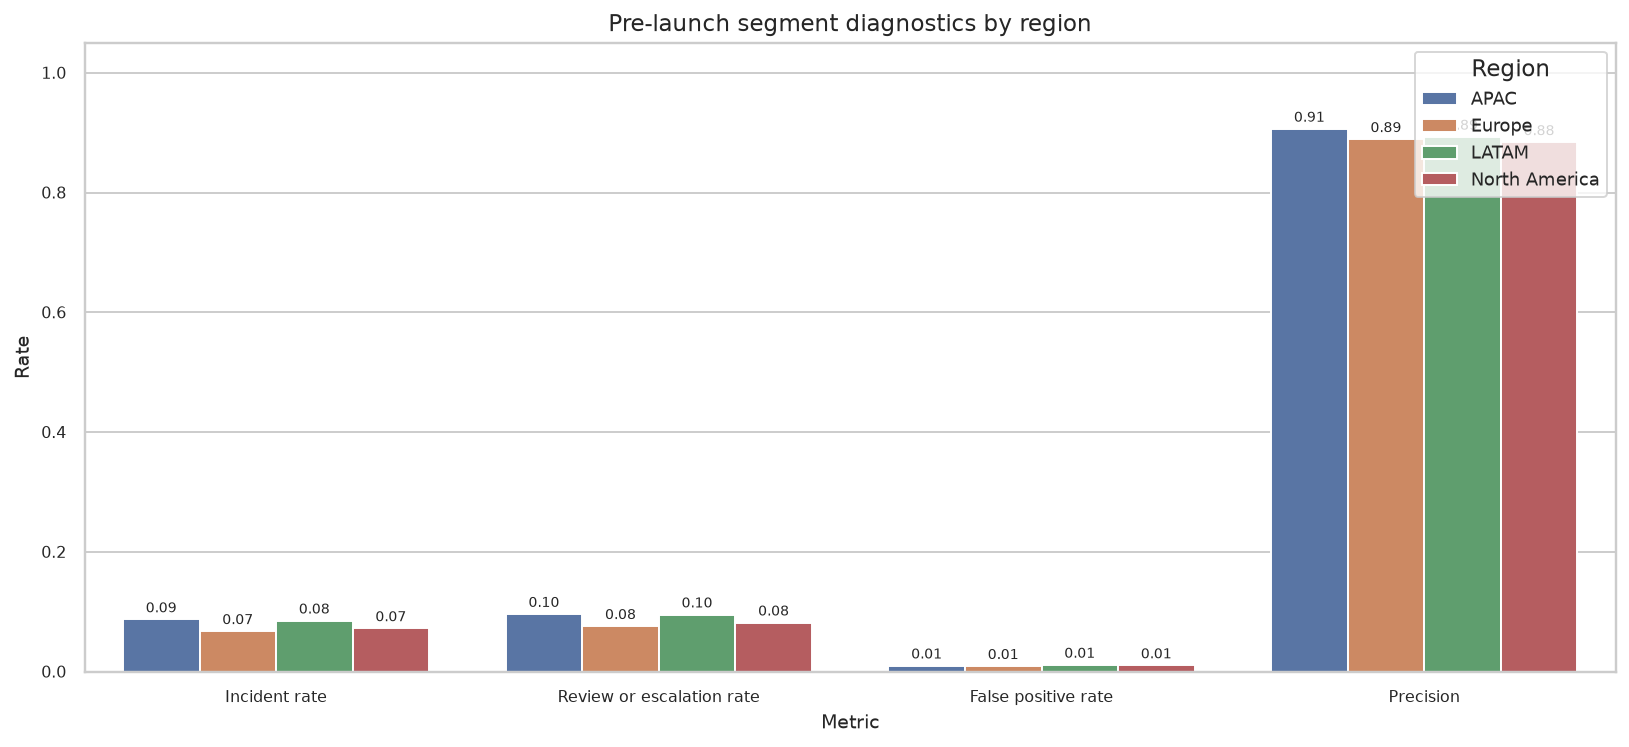

In [13]:
# Section focus: 10. Segment Diagnostics Before Launch.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

seg_long = region_metrics.melt(
    id_vars='region',
    value_vars=['incident_rate', 'review_or_escalation_rate', 'false_positive_rate', 'precision'],
    var_name='metric',
    value_name='value',
)
seg_labels = {
    'incident_rate': 'Incident rate',
    'review_or_escalation_rate': 'Review or escalation rate',
    'false_positive_rate': 'False positive rate',
    'precision': 'Precision',
}
seg_long['metric'] = seg_long['metric'].map(seg_labels)

fig, ax = plt.subplots(figsize=(11.8, 5.5))
sns.barplot(data=seg_long, x='metric', y='value', hue='region', ax=ax)
ax.set_title('Pre-launch segment diagnostics by region')
ax.set_xlabel('Metric')
ax.set_ylabel('Rate')
ax.set_ylim(0, max(1.05, seg_long['value'].max() * 1.15))
ax.legend(title='Region', frameon=True, loc='upper right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

Segment diagnostics are a launch gate. If a region or tier has much higher false positive burden with weak precision, the team should review features, thresholds, data quality, and operational context before launch.

Treat this result as an alerting diagnostic. In Segment Diagnostics Before Launch, the important question is whether the score separates real operational risk from routine variation, measurement noise, or known seasonality. The output is useful when it tells the reviewer where to look first.


## 11. Explanation Packet for a High-Priority Alert

For a reviewer, the useful questions are *why is the score high?*, *what evidence family is active?*, *what action is recommended?*, and *what should be checked next?*

In [14]:
explain_pool = scores.loc[scores['action'].isin(['human_review', 'escalate'])].sort_values('ensemble_score', ascending=False)
example = explain_pool.iloc[0]
example_idx = example.name

z_example = robust_z_current.loc[example_idx, feature_columns]
positive_z = z_example.clip(lower=0)
contributions = (positive_z.pow(2) * feature_weights).sort_values(ascending=False)
contrib_df = (
    contributions.reset_index()
    .rename(columns={'index': 'feature', 0: 'contribution'})
)
contrib_df['feature_label'] = contrib_df['feature'].map(feature_labels)
contrib_df['share_of_positive_deviation'] = contrib_df['contribution'] / contrib_df['contribution'].sum()
contrib_df.head(8).round(3)

,feature,contribution,feature_label,share_of_positive_deviation
0,chargeback_rate,537.734,Chargeback rate,0.891
1,inventory_mismatch_rate,40.840,Inventory mismatch rate,0.068
2,refund_rate,19.527,Refund rate,0.032
3,log_payout_amount,1.833,Payout amount,0.003
4,api_error_rate,1.801,API error rate,0.003
5,support_ticket_rate,1.744,Support-ticket rate,0.003
6,log_orders,0.040,Order volume,0.000
7,failed_login_rate,0.000,Failed-login rate,0.000


Treat this result as an alerting diagnostic. In Explanation Packet for a High-Priority Alert, the important question is whether the score separates real operational risk from routine variation, measurement noise, or known seasonality. A segment-level signal should narrow the investigation path.


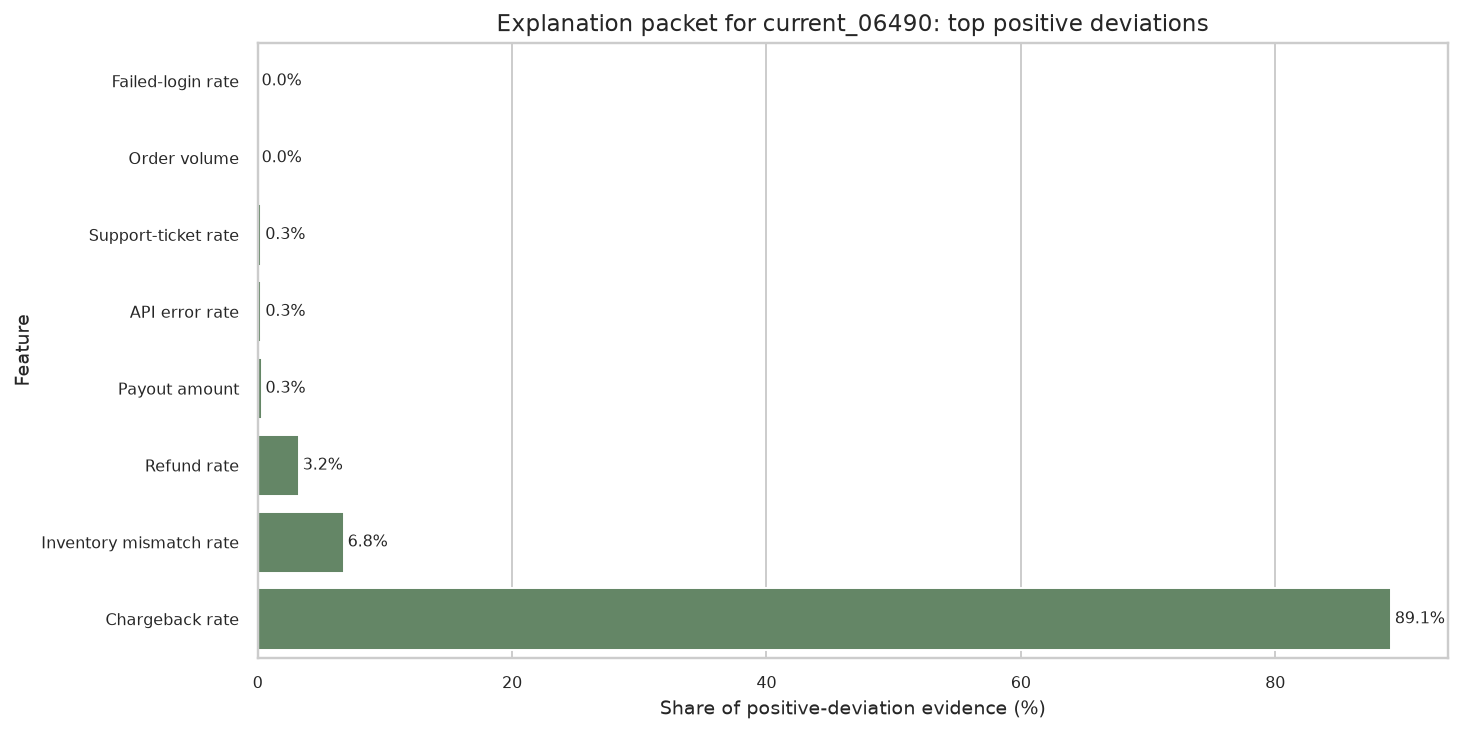

,field,value
0,case_id,current_06490
1,recommended_action,escalate
2,ensemble_score,1.000
3,simulated_case_type,payout_abuse
4,confirmed_incident,1
5,security_evidence_count,1
6,financial_evidence_count,3
7,operations_evidence_count,0
8,top_evidence_features,"Chargeback rate, Inventory mismatch rate, Refund rate, Payout amount"
9,next_review_step,Check raw evidence in restricted case tool; do not infer root cause from score alone.


In [15]:
# Section focus: 11. Explanation Packet for a High-Priority Alert.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

plot_contrib = contrib_df.head(8).copy()
plot_contrib['share_pct'] = 100 * plot_contrib['share_of_positive_deviation']
plot_contrib = plot_contrib.sort_values('share_pct')
fig, ax = plt.subplots(figsize=(10.6, 5.4))
sns.barplot(data=plot_contrib, x='share_pct', y='feature_label', color='#5e8c61', ax=ax)
ax.set_title(f'Explanation packet for {example.case_id}: top positive deviations')
ax.set_xlabel('Share of positive-deviation evidence (%)')
ax.set_ylabel('Feature')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

explanation_packet = pd.DataFrame([
    {'field': 'case_id', 'value': example.case_id},
    {'field': 'recommended_action', 'value': example.action},
    {'field': 'ensemble_score', 'value': f'{example.ensemble_score:.3f}'},
    {'field': 'simulated_case_type', 'value': example.anomaly_type},
    {'field': 'confirmed_incident', 'value': int(example.confirmed_incident)},
    {'field': 'security_evidence_count', 'value': int(example.security_evidence_count)},
    {'field': 'financial_evidence_count', 'value': int(example.financial_evidence_count)},
    {'field': 'operations_evidence_count', 'value': int(example.operations_evidence_count)},
    {'field': 'top_evidence_features', 'value': ', '.join(contrib_df['feature_label'].head(4).tolist())},
    {'field': 'next_review_step', 'value': 'Check raw evidence in restricted case tool; do not infer root cause from score alone.'},
])
explanation_packet

The explanation packet is intentionally modest. It explains the score under the scoring rule. It does not claim root cause. The reviewer still needs case history, event timelines, account ownership, system logs, and business context.

For Explanation Packet for a High-Priority Alert, focus on what the alert would make an analyst do next: investigate, suppress, monitor, or revise the rule.


## 12. Monitoring Dashboard

After launch, the system should monitor action volume, median score, known-event suppressions, and incident mix over time. The dashboard should distinguish system health from case investigation.

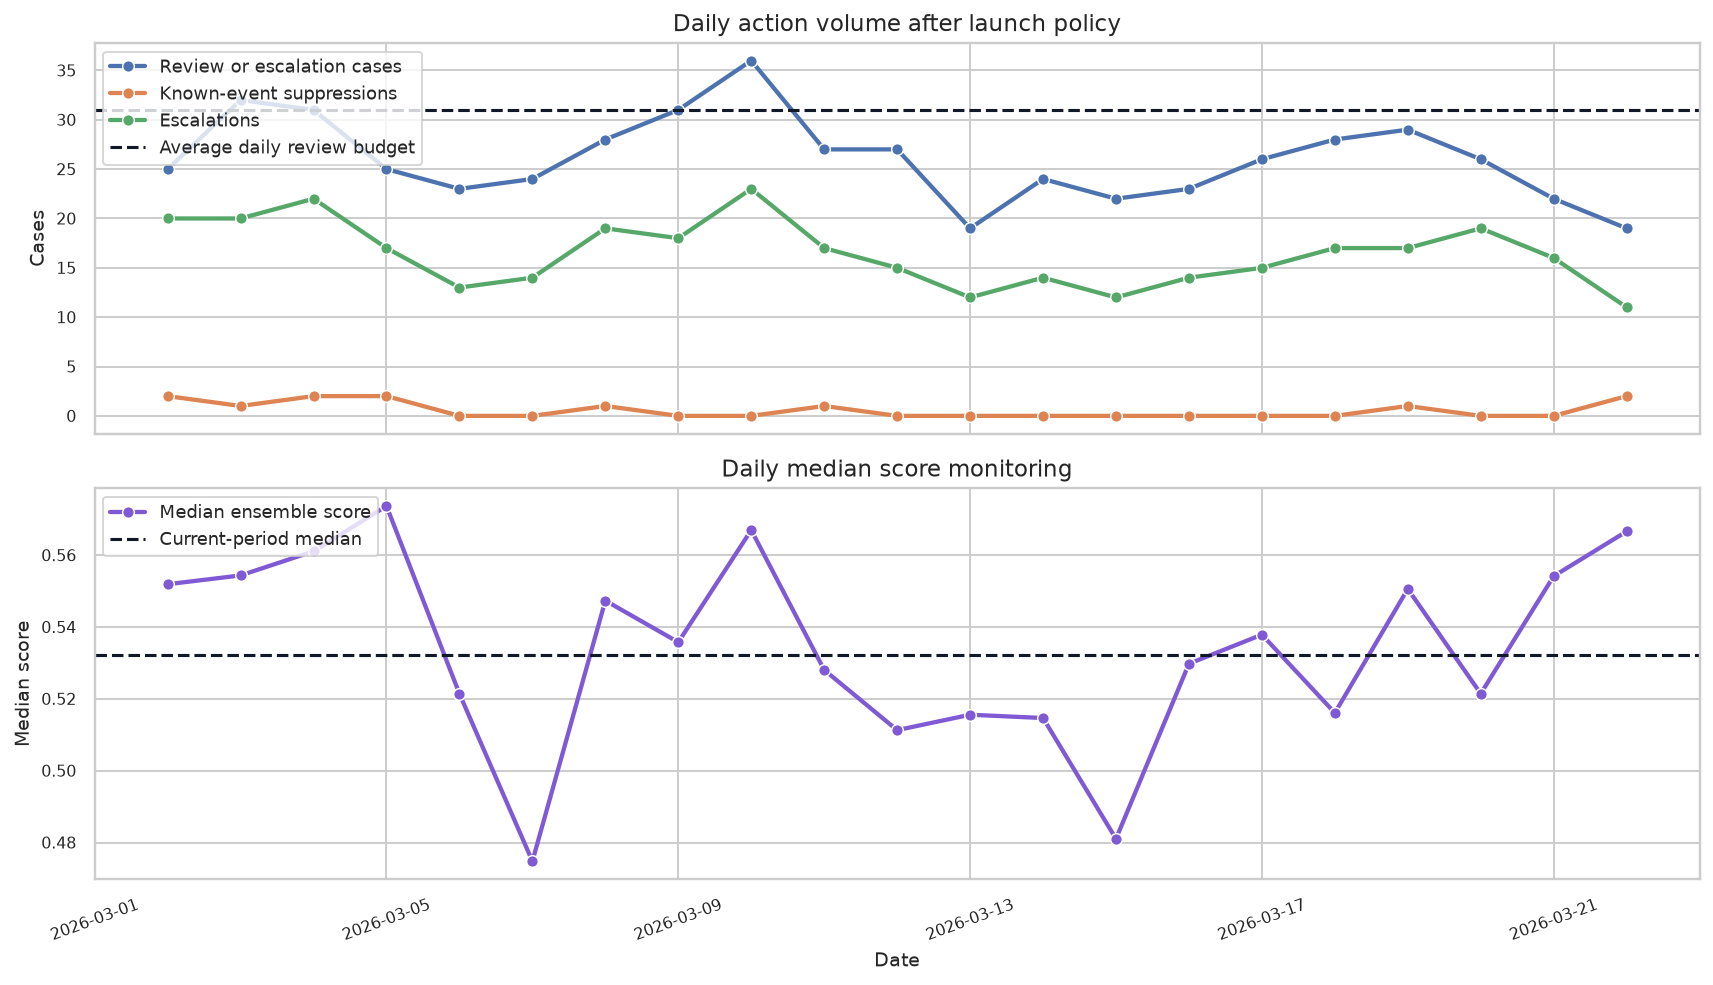

,event_date,cases,acted_cases,escalations,suppressed_known_events,median_score,confirmed_incidents
13,2026-03-15,328,22,12,0,0.481,21
14,2026-03-16,292,23,14,0,0.530,21
15,2026-03-17,315,26,15,0,0.538,22
16,2026-03-18,294,28,17,0,0.516,23
17,2026-03-19,334,29,17,1,0.551,26
18,2026-03-20,304,26,19,0,0.521,25
19,2026-03-21,307,22,16,0,0.554,21
20,2026-03-22,283,19,11,2,0.567,15


In [16]:
# Section focus: 12. Monitoring Dashboard.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

daily = (
    scores.assign(
        acted=scores['action'].isin(['human_review', 'escalate']),
        suppressed=scores['action'].eq('monitor_known_event'),
    )
    .groupby('event_date')
    .agg(
        cases=('case_id', 'count'),
        acted_cases=('acted', 'sum'),
        escalations=('action', lambda s: (s == 'escalate').sum()),
        suppressed_known_events=('suppressed', 'sum'),
        median_score=('ensemble_score', 'median'),
        confirmed_incidents=('confirmed_incident', 'sum'),
    )
    .reset_index()
    .sort_values('event_date')
)

fig, axes = plt.subplots(2, 1, figsize=(12.4, 7.2), sharex=True)
sns.lineplot(data=daily, x='event_date', y='acted_cases', marker='o', linewidth=2.2, label='Review or escalation cases', ax=axes[0])
sns.lineplot(data=daily, x='event_date', y='suppressed_known_events', marker='o', linewidth=2.2, label='Known-event suppressions', ax=axes[0])
sns.lineplot(data=daily, x='event_date', y='escalations', marker='o', linewidth=2.2, label='Escalations', ax=axes[0])
axes[0].axhline(review_capacity / daily.shape[0], color='#111827', linestyle='--', linewidth=1.6, label='Average daily review budget')
axes[0].set_title('Daily action volume after launch policy')
axes[0].set_ylabel('Cases')
axes[0].legend(frameon=True, loc='upper left')

sns.lineplot(data=daily, x='event_date', y='median_score', marker='o', linewidth=2.2, color='#805ad5', label='Median ensemble score', ax=axes[1])
axes[1].axhline(scores['ensemble_score'].median(), color='#111827', linestyle='--', linewidth=1.6, label='Current-period median')
axes[1].set_title('Daily median score monitoring')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Median score')
axes[1].legend(frameon=True, loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

daily.tail(8).round(3)

Monitoring catches anomalies and detects when the detector itself is producing too many cases, suppressing too many known events, or drifting away from the reference baseline.

Monitoring Dashboard should be read as an operations question. The practical test is whether the score points to something worth reviewing.


## 13. Privacy-Aware Audit Log

The launch system should store enough information to reconstruct decisions without exposing unnecessary raw telemetry.

In [17]:
# Section focus: 13. Privacy-Aware Audit Log.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

audit_candidates = scores.loc[scores['action'].isin(['human_review', 'escalate', 'monitor_known_event'])].sort_values('ensemble_score', ascending=False).head(12)

def top_feature_names(row_index, n=3):
    """Carry out the top feature names step used in the 17. Capstone: Anomaly Detection Decision Pipeline workflow.
    
    Parameters
    ----------
    row_index : object
        Single observation or record being converted, scored, or summarized.
    n : object
        Number of observations or simulation units used by the calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the top feature names calculation and reused by later cells.
    """
    z = robust_z_current.loc[row_index, feature_columns].clip(lower=0)
    contrib = (z.pow(2) * feature_weights).sort_values(ascending=False).head(n)
    return ', '.join([feature_labels[x] for x in contrib.index])

audit_log = pd.DataFrame({
    'audit_id': [f'audit_{i:04d}' for i in range(len(audit_candidates))],
    'case_id_hash': [f'hash_{abs(hash(x)) % 10**8:08d}' for x in audit_candidates['case_id']],
    'score_version': 'anomaly-capstone-v1.0',
    'policy_version': 'review-threshold-utility-v1',
    'action': audit_candidates['action'].to_numpy(),
    'score_bucket': pd.cut(audit_candidates['ensemble_score'], bins=[0, 0.80, 0.90, 0.97, 1.0], labels=['low', 'medium', 'high', 'critical'], include_lowest=True).astype(str).to_numpy(),
    'evidence_count': audit_candidates['evidence_count'].to_numpy(),
    'coarse_region': audit_candidates['region'].to_numpy(),
    'seller_tier': audit_candidates['seller_tier'].to_numpy(),
    'top_evidence_families': [top_feature_names(idx) for idx in audit_candidates.index],
    'retention_days': np.where(audit_candidates['action'].eq('escalate'), 365, np.where(audit_candidates['action'].eq('human_review'), 180, 60)),
})

audit_log

,audit_id,case_id_hash,score_version,policy_version,action,score_bucket,evidence_count,coarse_region,seller_tier,top_evidence_families,retention_days
0,audit_0000,hash_23954002,anomaly-capstone-v1.0,review-threshold-utility-v1,escalate,critical,4,LATAM,growth,"Chargeback rate, Inventory mismatch rate, Refund rate",365
1,audit_0001,hash_35423857,anomaly-capstone-v1.0,review-threshold-utility-v1,escalate,critical,5,Europe,long_tail,"Chargeback rate, Inventory mismatch rate, Refund rate",365
2,audit_0002,hash_89359297,anomaly-capstone-v1.0,review-threshold-utility-v1,escalate,critical,5,Europe,growth,"Chargeback rate, Inventory mismatch rate, Refund rate",365
3,audit_0003,hash_72391098,anomaly-capstone-v1.0,review-threshold-utility-v1,escalate,critical,4,Europe,growth,"Chargeback rate, Inventory mismatch rate, Refund rate",365
4,audit_0004,hash_74024618,anomaly-capstone-v1.0,review-threshold-utility-v1,escalate,critical,4,APAC,long_tail,"API error rate, Queue delay, Support-ticket rate",365
5,audit_0005,hash_44868411,anomaly-capstone-v1.0,review-threshold-utility-v1,escalate,critical,6,North America,growth,"Chargeback rate, Refund rate, Inventory mismatch rate",365
6,audit_0006,hash_96742167,anomaly-capstone-v1.0,review-threshold-utility-v1,escalate,critical,5,Europe,long_tail,"API error rate, Queue delay, Support-ticket rate",365
7,audit_0007,hash_52781958,anomaly-capstone-v1.0,review-threshold-utility-v1,escalate,critical,6,North America,enterprise,"Inventory mismatch rate, Chargeback rate, API error rate",365
8,audit_0008,hash_12712455,anomaly-capstone-v1.0,review-threshold-utility-v1,escalate,critical,6,North America,growth,"Failed-login rate, Device churn, Chargeback rate",365
9,audit_0009,hash_02404709,anomaly-capstone-v1.0,review-threshold-utility-v1,escalate,critical,4,North America,long_tail,"Failed-login rate, Chargeback rate, Device churn",365


The audit log avoids raw location trails, raw device identifiers, and exact monetary details. It stores score versions, policy versions, coarse context, evidence families, and retention periods. This is enough for governance review without turning the audit table into a sensitive data lake.

Treat this result as an alerting diagnostic. In Privacy-Aware Audit Log, the important question is whether the score separates real operational risk from routine variation, measurement noise, or known seasonality. This view should turn the alert into a focused follow-up question.


## 14. Launch Readiness Checklist

A launch packet should include a checklist. The exact thresholds below are illustrative; in practice they should come from the risk owner, operations owner, legal/privacy owner, and analyst team.

In [18]:
queue_volume = int(scores['action'].isin(['human_review', 'escalate']).sum())
precision = scores.loc[acted, 'confirmed_incident'].mean()
recall = scores.loc[acted, 'confirmed_incident'].sum() / max(scores['confirmed_incident'].sum(), 1)
region_fpr_gap = region_metrics['false_positive_rate'].max() - region_metrics['false_positive_rate'].min()
known_event_suppressed = int(scores['action'].eq('monitor_known_event').sum())
escalations = int(scores['action'].eq('escalate').sum())

checks = pd.DataFrame([
    {'check': 'Review volume is within capacity', 'value': queue_volume, 'criterion': f'<= {review_capacity}', 'pass': queue_volume <= review_capacity},
    {'check': 'Precision is operationally acceptable', 'value': precision, 'criterion': '>= 0.80', 'pass': precision >= 0.80},
    {'check': 'Recall is sufficient for launch monitoring', 'value': recall, 'criterion': '>= 0.55', 'pass': recall >= 0.55},
    {'check': 'Regional false-positive gap is bounded', 'value': region_fpr_gap, 'criterion': '<= 0.05', 'pass': region_fpr_gap <= 0.05},
    {'check': 'Known campaigns are not flooding review', 'value': known_event_suppressed, 'criterion': 'suppression rule active', 'pass': known_event_suppressed > 0},
    {'check': 'Escalations require multi-evidence support', 'value': scores.loc[scores['action'].eq('escalate'), 'evidence_count'].min(), 'criterion': '>= 4 when escalated', 'pass': scores.loc[scores['action'].eq('escalate'), 'evidence_count'].min() >= 4 if escalations else True},
    {'check': 'Audit log contains policy and score versions', 'value': int(audit_log[['score_version', 'policy_version']].notna().all(axis=None)), 'criterion': '1', 'pass': audit_log[['score_version', 'policy_version']].notna().all(axis=None)},
])
checks['status'] = np.where(checks['pass'], 'PASS', 'REVIEW')
checks

,check,value,criterion,pass,status
0,Review volume is within capacity,547.000000,<= 650,True,PASS
1,Precision is operationally acceptable,0.890311,>= 0.80,True,PASS
2,Recall is sufficient for launch monitoring,1.000000,>= 0.55,True,PASS
3,Regional false-positive gap is bounded,0.002118,<= 0.05,True,PASS
4,Known campaigns are not flooding review,12.000000,suppression rule active,True,PASS
5,Escalations require multi-evidence support,4.000000,>= 4 when escalated,True,PASS
6,Audit log contains policy and score versions,1.000000,1,True,PASS


This output matters because anomaly detection is both a scoring exercise and an operating system. For Launch Readiness Checklist, the result should tell us which alerts are actionable, which are ambiguous, and where human review is needed. The implication is a triage policy with an investigation path.


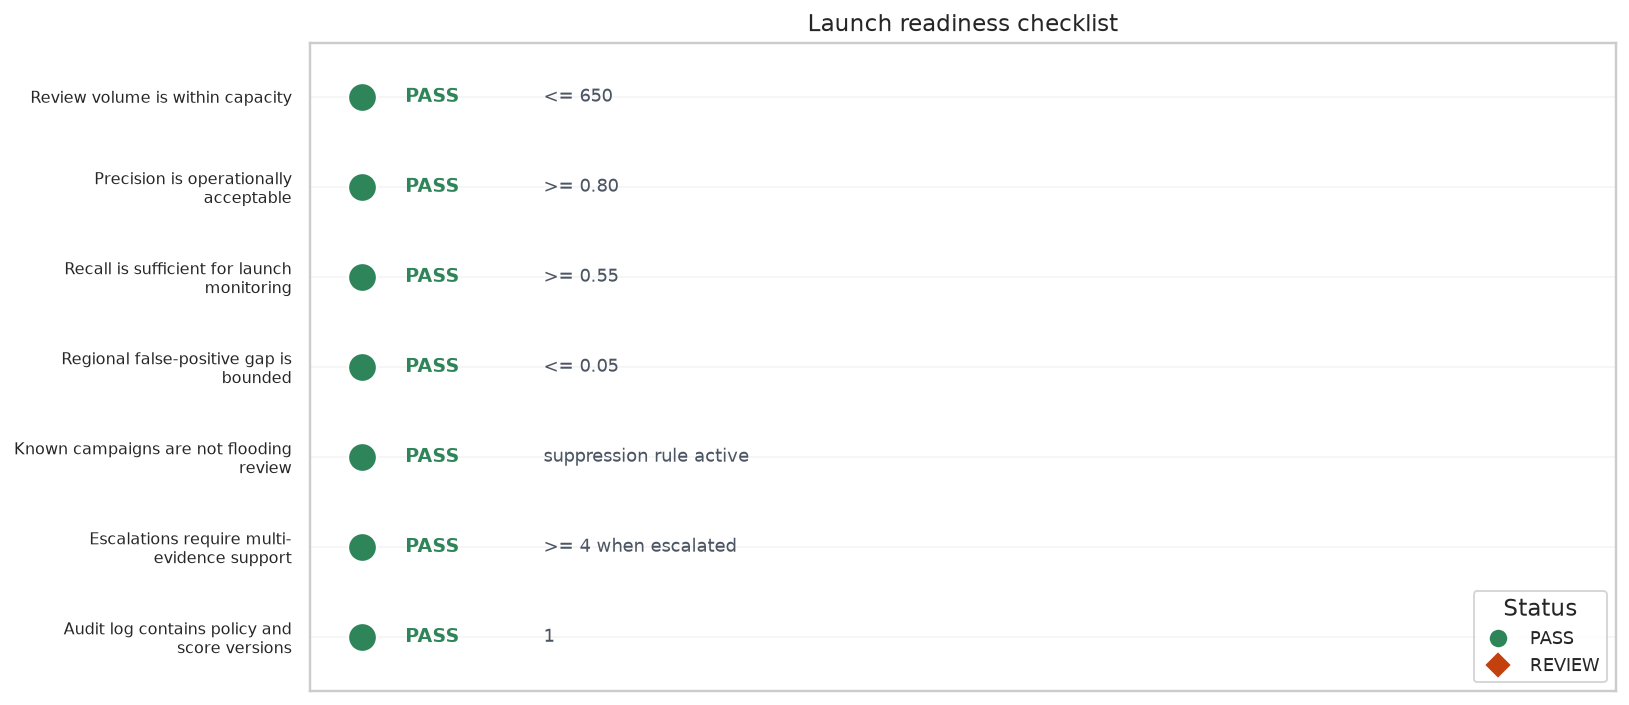

In [19]:
# Section focus: 14. Launch Readiness Checklist.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, ax = plt.subplots(figsize=(11.8, 5.2))
plot_checks = checks.copy().iloc[::-1].reset_index(drop=True)
plot_checks['y'] = np.arange(len(plot_checks))
plot_checks['check_short'] = plot_checks['check'].str.wrap(32)
status_colors = {'PASS': '#2f855a', 'REVIEW': '#c2410c'}
status_markers = {'PASS': 'o', 'REVIEW': 'D'}

for _, row in plot_checks.iterrows():
    color = status_colors[row['status']]
    ax.scatter(0, row['y'], s=220, color=color, marker=status_markers[row['status']], edgecolor='white', linewidth=1.1, zorder=3)
    ax.text(0.10, row['y'], row['status'], va='center', ha='left', fontsize=10, fontweight='bold', color=color)
    ax.text(0.42, row['y'], row['criterion'], va='center', ha='left', fontsize=9.5, color='#4b5563')

ax.set_yticks(plot_checks['y'])
ax.set_yticklabels(plot_checks['check_short'])
ax.set_xlim(-0.12, 2.9)
ax.set_ylim(-0.6, len(plot_checks) - 0.4)
ax.set_title('Launch readiness checklist')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.grid(axis='y', alpha=0.18)
legend_handles = [
    Line2D([0], [0], marker=status_markers[label], color='w', label=label, markerfacecolor=color, markeredgecolor='white', markersize=10)
    for label, color in status_colors.items()
]
ax.legend(handles=legend_handles, title='Status', frameon=True, loc='lower right')
plt.tight_layout()
plt.show()

The checklist is not bureaucracy. It is the final bridge from model performance to decision readiness. A detector with strong average precision can still fail launch readiness if it overwhelms analysts, creates segment burden, or lacks auditability.

Read the result through the lens of alert quality. In Launch Readiness Checklist, high scores, unusual clusters, or shifted distributions should be connected to the cost of missed incidents and false alarms. A useful detector is one whose outputs can be investigated, explained, and governed.


## 15. Decision Memo

The final memo should be written in language that risk, product, operations, and data science owners can all inspect.

In [20]:
failed_checks = checks.loc[~checks['pass'], 'check'].tolist()
status_sentence = 'All launch checks passed.' if not failed_checks else 'Launch requires review for: ' + '; '.join(failed_checks)

display(Markdown(f'''
### Launch Recommendation

Proceed with a monitored pilot of the anomaly detection decision pipeline, using the selected review threshold **{review_threshold:.3f}** and escalation threshold **{escalation_threshold:.3f}**.

### Expected Operating Profile

- Current-period rows scored: **{len(scores):,}**.
- Human review or escalation volume: **{queue_volume:,}** cases against a capacity of **{review_capacity:,}**.
- Precision among reviewed or escalated cases: **{precision:.2%}**.
- Recall among confirmed incidents: **{recall:.2%}**.
- Known campaign cases suppressed to monitoring: **{known_event_suppressed:,}**.
- Regional false-positive-rate gap: **{region_fpr_gap:.3f}**.

### Required Guardrails

1. Keep known-event annotations in the scoring context so benign campaigns do not flood the review queue.
2. Require at least four active evidence families before escalation.
3. Log score version, policy version, action, coarse segment, evidence families, and retention deadline for every reviewed or suppressed case.
4. Monitor daily action volume, median score, escalation volume, known-event suppressions, and segment false-positive rates.
5. Revalidate thresholds after major product, traffic, instrumentation, or policy changes.

### Launch Status

{status_sentence}
'''))


### Launch Recommendation

Proceed with a monitored pilot of the anomaly detection decision pipeline, using the selected review threshold **0.983** and escalation threshold **1.000**.

### Expected Operating Profile

- Current-period rows scored: **6,500**.
- Human review or escalation volume: **547** cases against a capacity of **650**.
- Precision among reviewed or escalated cases: **89.03%**.
- Recall among confirmed incidents: **100.00%**.
- Known campaign cases suppressed to monitoring: **12**.
- Regional false-positive-rate gap: **0.002**.

### Required Guardrails

1. Keep known-event annotations in the scoring context so benign campaigns do not flood the review queue.
2. Require at least four active evidence families before escalation.
3. Log score version, policy version, action, coarse segment, evidence families, and retention deadline for every reviewed or suppressed case.
4. Monitor daily action volume, median score, escalation volume, known-event suppressions, and segment false-positive rates.
5. Revalidate thresholds after major product, traffic, instrumentation, or policy changes.

### Launch Status

All launch checks passed.


Read the result through the lens of alert quality. In Decision Memo, high scores, unusual clusters, or shifted distributions should be connected to the cost of missed incidents and false alarms. A useful detector is one whose outputs can be investigated, explained, and governed.


## 16. What This Capstone Integrated

This notebook brought together the full course:

| Course theme | Capstone component |
|---|---|
| Statistical baselines | Robust z-score detector and reference period |
| Tree-based anomaly detection | Isolation Forest score |
| Reconstruction-based detection | PCA reconstruction error |
| Thresholds and costs | Utility frontier and capacity constraint |
| Evaluation with imperfect labels | Precision-at-k, recall-at-capacity, delayed-label framing |
| Explainability | Feature-level positive deviation packet |
| Root-cause caution | Explanation packet does not claim cause |
| Governance | Segment metrics, known-event suppression, review capacity |
| Privacy | Minimized audit log and coarse context fields |
| Deployment monitoring | Daily score and action dashboard |

## 17. Key Takeaways

- A launch-ready anomaly system is a decision pipeline, not a model artifact.
- Detector ensembles can stabilize evidence, but they still need cost-aware thresholds and capacity constraints.
- Known benign events should be part of the policy context, otherwise normal business activity becomes review burden.
- Explanation packets should guide investigation without claiming root cause.
- Segment diagnostics, audit records, privacy controls, and monitoring dashboards are part of the system specification.
- The final output of the work is a launch memo that names actions, guardrails, thresholds, and revision triggers.

## References

Bondi, E., Koster, R., Sheahan, H., Chadwick, M., Bachrach, Y., Cemgil, T., Paquet, U., Dvijotham, K., & Weller, A. (2022). Role of human-AI interaction in selective prediction. *Proceedings of the AAAI Conference on Artificial Intelligence, 36*(5), 5286-5294. [https://doi.org/10.1609/aaai.v36i5.20465](https://doi.org/10.1609/aaai.v36i5.20465)

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

Dwork, C., & Roth, A. (2014). The algorithmic foundations of differential privacy. *Foundations and Trends in Theoretical Computer Science, 9*(3-4), 211-487. [https://doi.org/10.1561/0400000042](https://doi.org/10.1561/0400000042)

Hardt, M., Price, E., & Srebro, N. (2016). Equality of opportunity in supervised learning. *arXiv*. [https://doi.org/10.48550/arXiv.1610.02413](https://doi.org/10.48550/arXiv.1610.02413)

Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation Forest. *IEEE International Conference on Data Mining*, 413-422. [https://doi.org/10.1109/ICDM.2008.17](https://doi.org/10.1109/ICDM.2008.17)

Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2012). Isolation-based anomaly detection. *ACM Transactions on Knowledge Discovery from Data, 6*(1), 1-39. [https://doi.org/10.1145/2133360.2133363](https://doi.org/10.1145/2133360.2133363)

Wang, P., Xu, J., Ma, M., Lin, W., Pan, D., Wang, Y., & Chen, P. (2018). CloudRanger: Root cause identification for cloud native systems. *18th IEEE/ACM International Symposium on Cluster, Cloud and Grid Computing*, 492-502. [https://doi.org/10.1109/CCGRID.2018.00076](https://doi.org/10.1109/CCGRID.2018.00076)
